Autores: Cristian Cabrera y Álex Rafael de la Cruz

Notebook que contiene el EDA de los dataset que usamos para los entrenamiento de cada modelo

# Análisis exploratorio de datos

In [3]:
#imports
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Análisis EDA para dataset de CNN

In [ ]:
DIRECTORIO_DATOS = '../dataset_4_letras'

#### Recopilación de metadatos

In [5]:
palabras = []
rutas_imagenes = []
dimensiones = set()

for palabra in os.listdir(DIRECTORIO_DATOS):
    ruta_palabra = os.path.join(DIRECTORIO_DATOS, palabra)
    if os.path.isdir(ruta_palabra):
        imagenes = os.listdir(ruta_palabra)
        for img_name in imagenes:
            ruta_img = os.path.join(ruta_palabra, img_name)
            palabras.append(palabra)
            rutas_imagenes.append(ruta_img)
            
            # Cogemos la dimensión de la primera imagen de cada carpeta para comprobar
            if len(dimensiones) < 5: 
                img_test = cv2.imread(ruta_img)
                dimensiones.add(img_test.shape)

df_dataset = pd.DataFrame({'Palabra': palabras, 'Ruta': rutas_imagenes})

print(f"\nTotal de imágenes generadas: {len(df_dataset)}")
print(f"Total de palabras únicas (clases base): {df_dataset['Palabra'].nunique()}")
print(f"Dimensiones de las imágenes (Alto, Ancho, Canales): {list(dimensiones)[0]}")


Total de imágenes generadas: 20000
Total de palabras únicas (clases base): 50
Dimensiones de las imágenes (Alto, Ancho, Canales): (128, 497, 3)


#### Balanceo de palabras

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_23744\880230234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_palabras.index, y=conteo_palabras.values, palette="viridis")


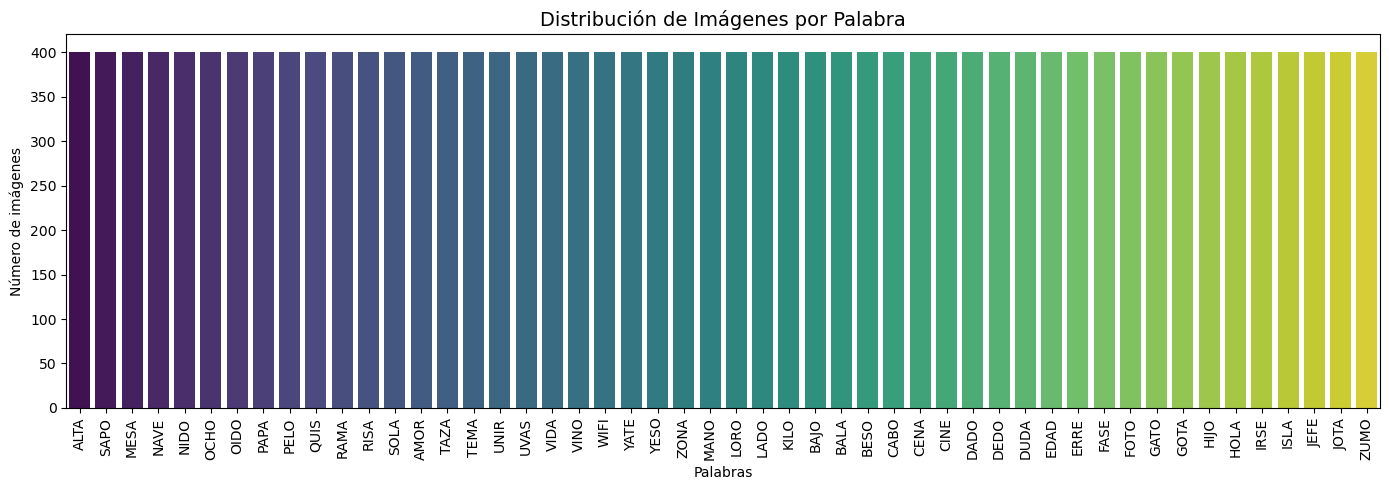

In [6]:
plt.figure(figsize=(14, 5))
conteo_palabras = df_dataset['Palabra'].value_counts()
sns.barplot(x=conteo_palabras.index, y=conteo_palabras.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Distribución de Imágenes por Palabra", fontsize=14)
plt.ylabel("Número de imágenes")
plt.xlabel("Palabras")
plt.tight_layout()
plt.show()

#### Frecuencia de letras individuales

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_23744\2030679489.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Letra', y='Frecuencia', data=df_letras, palette="magma")


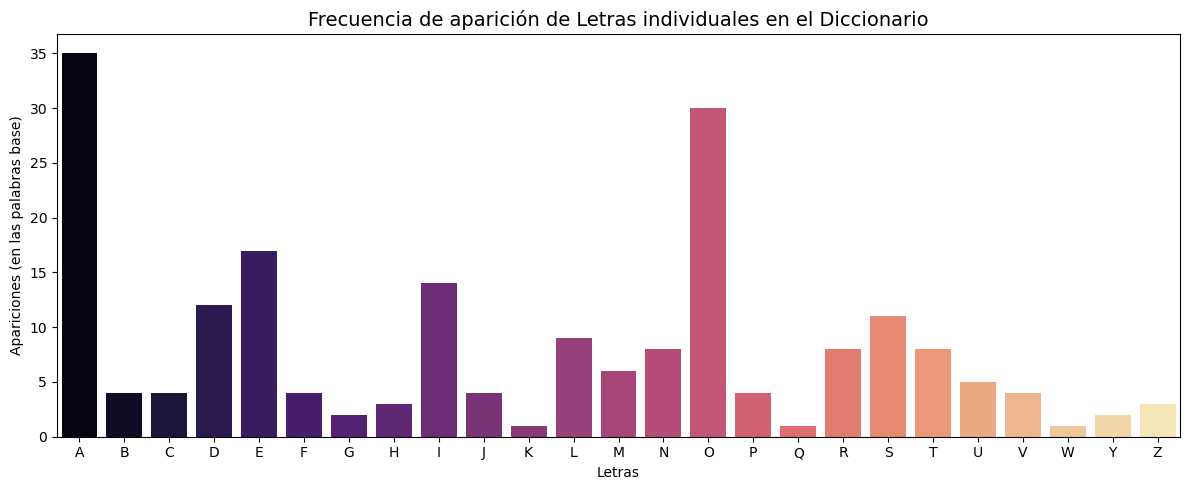

In [7]:
# Como el modelo predice letras, esta es la gráfica más importante para el EDA
todas_las_letras = "".join(df_dataset['Palabra'].unique())
conteo_letras = Counter(todas_las_letras)

# Convertir a DataFrame para Seaborn y ordenar alfabéticamente
df_letras = pd.DataFrame.from_dict(conteo_letras, orient='index', columns=['Frecuencia']).reset_index()
df_letras = df_letras.rename(columns={'index': 'Letra'}).sort_values('Letra')

plt.figure(figsize=(12, 5))
sns.barplot(x='Letra', y='Frecuencia', data=df_letras, palette="magma")
plt.title("Frecuencia de aparición de Letras individuales en el Diccionario", fontsize=14)
plt.ylabel("Apariciones (en las palabras base)")
plt.xlabel("Letras")
plt.tight_layout()
plt.show()

#### Visualización de muestra aleatoria

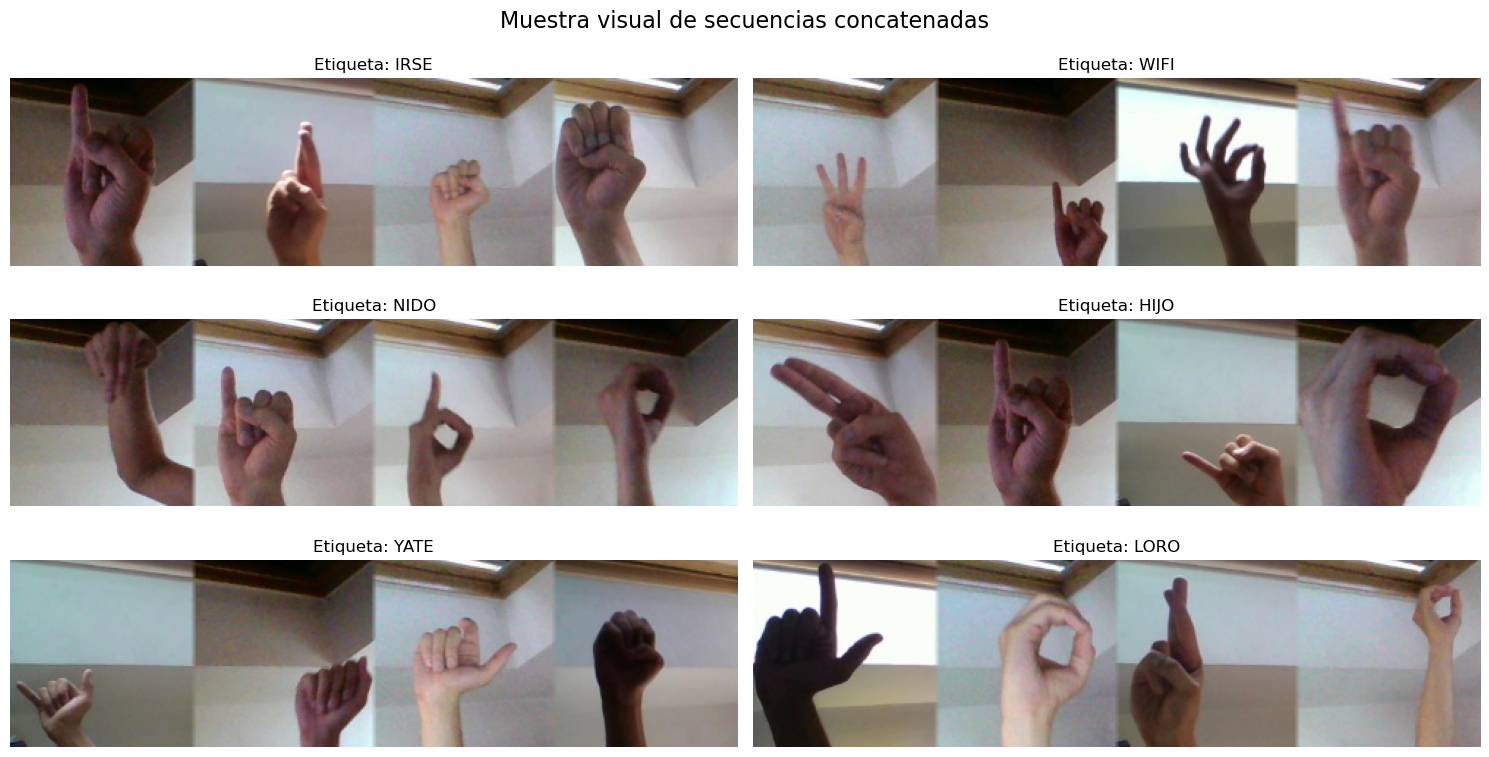

In [8]:
plt.figure(figsize=(15, 8))
muestras = df_dataset.sample(6)
for i, (index, row) in enumerate(muestras.iterrows()):
    plt.subplot(3, 2, i+1)
    img = cv2.imread(row['Ruta'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Etiqueta: {row['Palabra']}")
    plt.axis('off')
plt.suptitle("Muestra visual de secuencias concatenadas", fontsize=16)
plt.tight_layout()
plt.show()

#### Distribución de pixeles

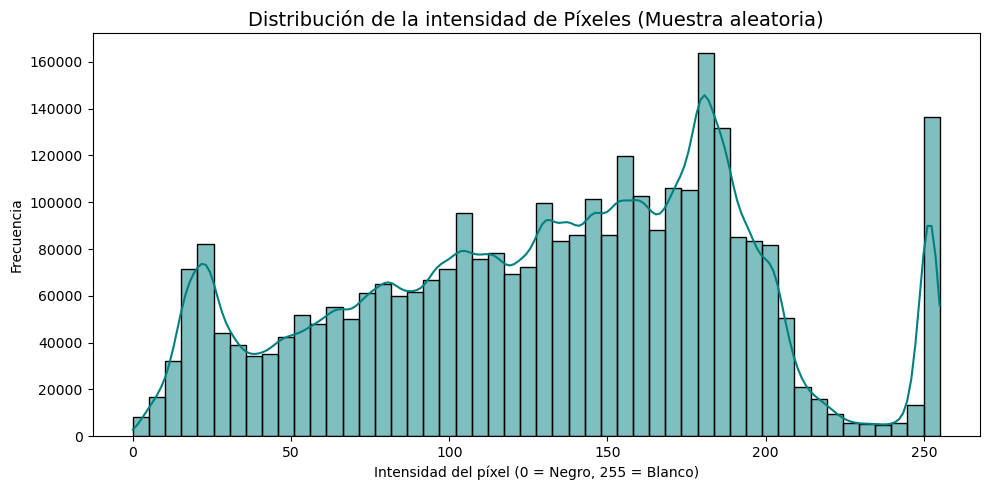

In [9]:
pixeles_muestra = []
for ruta in df_dataset['Ruta'].sample(50):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    pixeles_muestra.extend(img.flatten())

plt.figure(figsize=(10, 5))
sns.histplot(pixeles_muestra, bins=50, color="teal", kde=True)
plt.title("Distribución de la intensidad de Píxeles (Muestra aleatoria)", fontsize=14)
plt.xlabel("Intensidad del píxel (0 = Negro, 255 = Blanco)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Análisis EDA para dataset de CRNN

In [ ]:
RUTA_DATASET = '../dataset_robusto_crnn'

In [11]:

# Listar todos los archivos y extraer sus etiquetas
archivos = [f for f in os.listdir(RUTA_DATASET) if f.endswith('.jpg')]
etiquetas = [f.split('_')[0] for f in archivos]
longitudes = [len(etiq) for etiq in etiquetas]

print(f"Total de imágenes encontradas: {len(archivos)}")

Total de imágenes encontradas: 9000


Distribución por longitud de frecuencia

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_23744\766085858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=longitudes, palette="viridis")


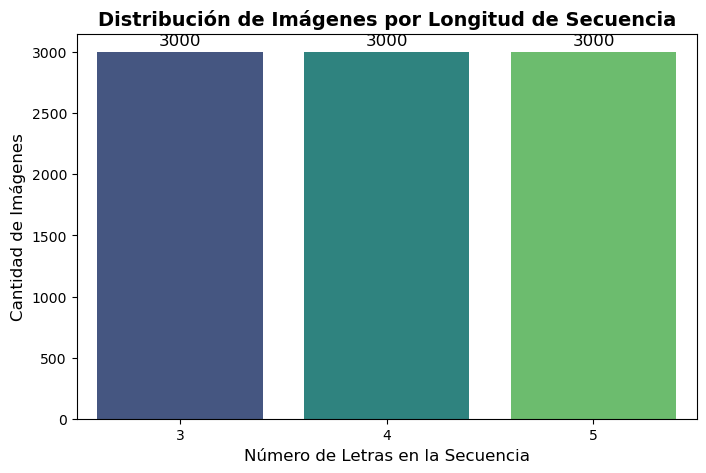

In [12]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=longitudes, palette="viridis")
plt.title('Distribución de Imágenes por Longitud de Secuencia', fontsize=14, fontweight='bold')
plt.xlabel('Número de Letras en la Secuencia', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)

# Añadir los números encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

Frecuencia de letras individuales

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_23744\475639763.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letras_ordenadas, y=frecuencias, palette="magma")


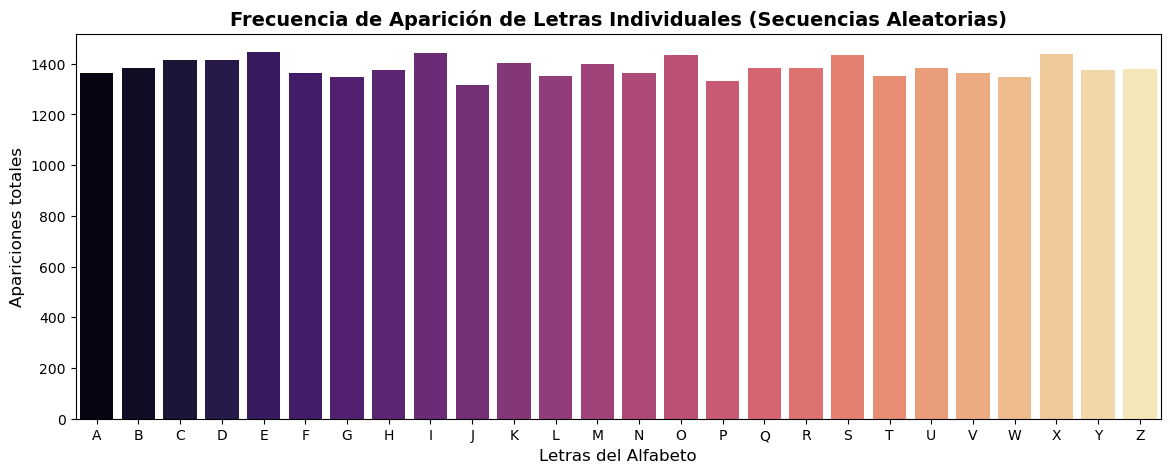

In [13]:
todas_las_letras = "".join(etiquetas)
conteo_letras = Counter(todas_las_letras)
letras_ordenadas = sorted(conteo_letras.keys())
frecuencias = [conteo_letras[l] for l in letras_ordenadas]

plt.figure(figsize=(14, 5))
sns.barplot(x=letras_ordenadas, y=frecuencias, palette="magma")
plt.title('Frecuencia de Aparición de Letras Individuales (Secuencias Aleatorias)', fontsize=14, fontweight='bold')
plt.xlabel('Letras del Alfabeto', fontsize=12)
plt.ylabel('Apariciones totales', fontsize=12)
plt.show()

Muestra de ejemplo

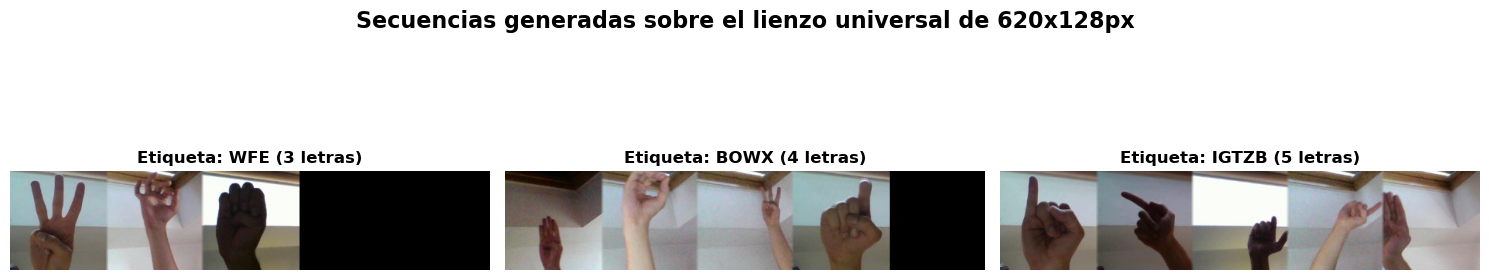

In [16]:
import random
# Seleccionamos una imagen aleatoria de 3, otra de 4 y otra de 5 letras
ejemplos = []
for l in [3, 4, 5]:
    archivos_len = [f for f in archivos if len(f.split('_')[0]) == l]
    ejemplos.append(random.choice(archivos_len))

plt.figure(figsize=(15, 4))
for i, archivo in enumerate(ejemplos):
    img = cv2.imread(os.path.join(RUTA_DATASET, archivo))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    etiqueta = archivo.split('_')[0]

    plt.subplot(1, 3, i+1)
    plt.imshow(img_rgb)
    plt.title(f"Etiqueta: {etiqueta} ({len(etiqueta)} letras)", fontweight='bold')
    plt.axis('off')
    
plt.suptitle("Secuencias generadas sobre el lienzo universal de 620x128px", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Distribución de pixeles

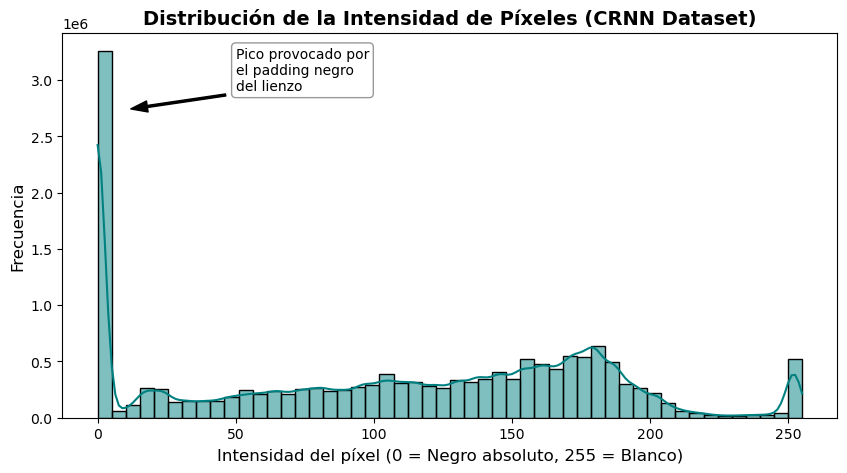

In [15]:
# Usamos una muestra de 200 imágenes aleatorias para no saturar la memoria
muestra_archivos = random.sample(archivos, min(200, len(archivos))) 
pixeles = []

for archivo in muestra_archivos:
    img = cv2.imread(os.path.join(RUTA_DATASET, archivo), cv2.IMREAD_GRAYSCALE)
    pixeles.extend(img.flatten())

plt.figure(figsize=(10, 5))
sns.histplot(pixeles, bins=50, color="teal", kde=True)
plt.title('Distribución de la Intensidad de Píxeles (CRNN Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Intensidad del píxel (0 = Negro absoluto, 255 = Blanco)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Añadimos un texto explicativo sobre el pico negro en la propia gráfica
plt.annotate('Pico provocado por\nel padding negro\ndel lienzo', xy=(10, plt.ylim()[1]*0.8), 
             xytext=(50, plt.ylim()[1]*0.85),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.show()